# Pricer d'Options — Black-Scholes, Monte Carlo & Arbre Binomial

## Pourquoi trois méthodes pour pricer la même chose ?

Une option vanille (call ou put européen) a une **formule fermée** : Black-Scholes. Pas besoin de simuler quoi que ce soit, le prix se calcule directement avec une formule mathématique. Mais cette formule a des limites : elle ne marche que pour des produits simples (option européenne, volatilité constante) et des hypothèses fortes (pas de dividende discret, marché sans friction...).

On va implémenter le pricing par **trois méthodes différentes**, dans cet ordre :

1. **Black-Scholes** (formule fermée) — la référence, le calcul "en un coup"
2. **Monte Carlo** (simulation) — la méthode générale, qui marche même quand il n'y a pas de formule fermée (c'est celle qu'on a utilisée pour l'autocall, qui n'a pas de formule fermée)
3. **Arbre binomial** — une méthode discrète qui a un avantage clé : elle gère les options **américaines** (exerçables à tout moment, pas seulement à l'échéance), ce que Black-Scholes et Monte Carlo "simple" ne savent pas faire facilement

Le but : vérifier que les trois méthodes convergent vers le même prix pour une option européenne (ça valide chaque implémentation), puis utiliser le binomial pour voir ce qui change avec une option américaine.

In [54]:
import numpy as np                  # calcul numérique (tableaux, fonctions mathématiques)
import pandas as pd                 # pour organiser les résultats en tableaux
import matplotlib.pyplot as plt     # pour les graphiques
from scipy.stats import norm        # loi normale : nécessaire pour la formule Black-Scholes (fonction de répartition N(x))

# Paramètres de l'option de référence, qu'on va utiliser pour tout le projet
S0 = 100       # prix actuel du sous-jacent (spot)
K = 100        # strike (prix d'exercice) — on commence "à la monnaie" (ATM), S0 = K
T = 1.0        # maturité en années (1 an)
r = 0.03       # taux sans risque (3%)
sigma = 0.20   # volatilité annualisée du sous-jacent (20%, une valeur typique pour une action)
q = 0.0        # taux de dividende (0% pour l'instant, on l'introduira plus tard pour le comparer à l'autocall)

## 1. Black-Scholes : la formule fermée

Black-Scholes donne le prix d'une option européenne directement, sans simulation, à partir de 5 paramètres (S0, K, T, r, sigma). La formule repose sur une idée : sous certaines hypothèses (volatilité constante, pas de friction de marché), on peut répliquer parfaitement le payoff de l'option en ajustant continuellement une position en sous-jacent et en cash — et le prix de l'option est le coût de cette stratégie de réplication.

La formule pour un **call** :

Call = S0 × e^(-qT) × N(d1) − K × e^(-rT) × N(d2)

Et pour un **put** (parité call-put) :

Put = K × e^(-rT) × N(-d2) − S0 × e^(-qT) × N(-d1)

où :
- d1 = [ln(S0/K) + (r − q + σ²/2) × T] / (σ × √T)
- d2 = d1 − σ × √T
- N(x) = fonction de répartition de la loi normale standard (la probabilité qu'une variable normale soit ≤ x)

**Intuition** : N(d2) s'interprète (sous la probabilité risque-neutre) comme la probabilité que l'option soit exercée. N(d1) est lié à la sensibilité du prix de l'option au sous-jacent (on retrouvera ça avec le delta). Le call vaut donc, grosso modo, "ce qu'on reçoit si on exerce" moins "ce qu'on paie si on exerce", chacun pondéré par sa probabilité.

In [55]:
def black_scholes(S0, K, T, r, sigma, q=0.0, option_type="call"):
    # d1 et d2 : les deux quantités intermédiaires de la formule
    d1 = (np.log(S0 / K) + (r - q + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    if option_type == "call":
        # formule du call : valeur actualisée du sous-jacent reçu moins valeur actualisée du strike payé
        price = S0 * np.exp(-q * T) * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    elif option_type == "put":
        # parité call-put : on inverse les termes et on utilise N(-d1), N(-d2)
        price = K * np.exp(-r * T) * norm.cdf(-d2) - S0 * np.exp(-q * T) * norm.cdf(-d1)
    else:
        raise ValueError("option_type doit être 'call' ou 'put'")  # garde-fou si on se trompe de valeur

    return price

# On teste sur notre option de référence (call ATM, S0=K=100, T=1an)
prix_call_bs = black_scholes(S0, K, T, r, sigma, q, option_type="call")
prix_put_bs = black_scholes(S0, K, T, r, sigma, q, option_type="put")

print(f"Prix du call (Black-Scholes) : {prix_call_bs:.4f}")
print(f"Prix du put (Black-Scholes) : {prix_put_bs:.4f}")

Prix du call (Black-Scholes) : 9.4134
Prix du put (Black-Scholes) : 6.4580


## 2. Monte Carlo : pricer en simulant

Même principe que pour l'autocall : on simule un grand nombre de trajectoires possibles du sous-jacent sous probabilité risque-neutre, on calcule le payoff de l'option pour chacune, on actualise, et on moyenne.

Pour une option vanille européenne, pas besoin de simuler toute la trajectoire jour par jour — seul le prix **final** (à maturité T) compte, puisque le payoff ne dépend que de S(T). On peut donc tirer S(T) directement en une seule étape :

S(T) = S0 × exp[(r − q − σ²/2) × T + σ × √T × Z]

Le payoff :
- Call : max(S(T) − K, 0) — on exerce seulement si le sous-jacent dépasse le strike
- Put : max(K − S(T), 0) — on exerce seulement si le sous-jacent est sous le strike

Le prix Monte Carlo = moyenne des payoffs actualisés. Comme c'est une estimation statistique (pas un calcul exact), elle a une **erreur** qui diminue en 1/√N quand le nombre de simulations N augmente — c'est ce qu'on va vérifier juste après.

In [56]:
def monte_carlo_price(S0, K, T, r, sigma, q=0.0, option_type="call", n_sims=100_000, seed=42):
    np.random.seed(seed)                                    # pour des résultats reproductibles

    Z = np.random.standard_normal(n_sims)                   # n_sims tirages aléatoires indépendants, loi normale standard

    # tirage direct de S(T), pas besoin de simuler les étapes intermédiaires pour une option vanille
    S_T = S0 * np.exp((r - q - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z)

    if option_type == "call":
        payoffs = np.maximum(S_T - K, 0)                     # payoff du call pour chaque trajectoire simulée
    elif option_type == "put":
        payoffs = np.maximum(K - S_T, 0)                     # payoff du put
    else:
        raise ValueError("option_type doit être 'call' ou 'put'")

    discounted_payoffs = payoffs * np.exp(-r * T)            # on actualise chaque payoff à aujourd'hui

    price = discounted_payoffs.mean()                        # le prix = la moyenne des payoffs actualisés
    std_error = discounted_payoffs.std() / np.sqrt(n_sims)    # erreur-type de cette estimation (écart-type / racine(N))

    return price, std_error

prix_call_mc, se_call = monte_carlo_price(S0, K, T, r, sigma, q, option_type="call", n_sims=100_000)

print(f"Prix du call (Monte Carlo, N=100 000) : {prix_call_mc:.4f}")
print(f"Erreur-type : {se_call:.4f}")
print(f"Prix du call (Black-Scholes, référence) : {prix_call_bs:.4f}")

Prix du call (Monte Carlo, N=100 000) : 9.4356
Erreur-type : 0.0447
Prix du call (Black-Scholes, référence) : 9.4134


## 3. Vérifier la convergence de Monte Carlo

L'erreur-type diminue en 1/√N : si on multiplie N par 100, l'erreur-type est divisée par 10. On va le vérifier concrètement en pricant avec plusieurs tailles d'échantillon, et en traçant comment le prix (et son erreur) se rapproche de la référence Black-Scholes.

      N  Prix MC  Erreur-type  Erreur absolue  Erreur abs / erreur-type
   1000 9.453927     0.454241        0.040524                  0.089212
  10000 9.412777     0.141748        0.000626                  0.004419
 100000 9.435604     0.044665        0.022201                  0.497051
1000000 9.398038     0.014091        0.015365                  1.090470
Pente de l'erreur-type en log-log : -0.503 (théorie : -0.5)


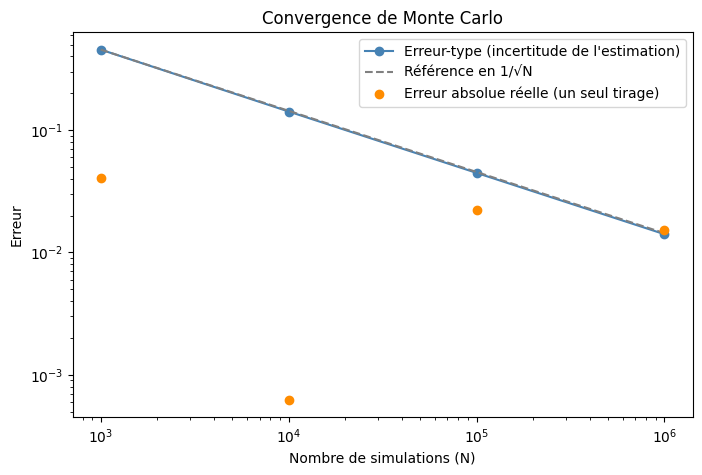

In [57]:
n_sims_list = [1_000, 10_000, 100_000, 1_000_000]   # tailles d'échantillon testées, x10 à chaque fois

resultats_convergence = []                            # un dict par taille testée

for n in n_sims_list:
    prix, se = monte_carlo_price(S0, K, T, r, sigma, q, option_type="call", n_sims=n)
    resultats_convergence.append({
        "N": n,
        "Prix MC": prix,
        "Erreur-type": se,                              # incertitude statistique de l'estimation : c'est elle qui suit 1/√N
        "Erreur absolue": abs(prix - prix_call_bs),     # écart réel à Black-Scholes pour CE tirage : aléatoire
    })

df_convergence = pd.DataFrame(resultats_convergence)
df_convergence["Erreur abs / erreur-type"] = df_convergence["Erreur absolue"] / df_convergence["Erreur-type"]   # ordre de grandeur : proche de 1 = normal
print(df_convergence.to_string(index=False))

# pente de l'erreur-type en échelle log-log : la théorie dit -0.5 (division par √10 quand N est multiplié par 10)
pente = np.polyfit(np.log(df_convergence["N"]), np.log(df_convergence["Erreur-type"]), 1)[0]
print(f"Pente de l'erreur-type en log-log : {pente:.3f} (théorie : -0.5)")

fig, ax = plt.subplots(figsize=(8, 5))
ax.loglog(df_convergence["N"], df_convergence["Erreur-type"], marker="o", color="steelblue",
          label="Erreur-type (incertitude de l'estimation)")
ref = df_convergence["Erreur-type"].iloc[0] * np.sqrt(df_convergence["N"].iloc[0] / df_convergence["N"])   # courbe 1/√N ancrée sur le 1er point
ax.loglog(df_convergence["N"], ref, linestyle="--", color="gray", label="Référence en 1/√N")
ax.scatter(df_convergence["N"], df_convergence["Erreur absolue"], color="darkorange", zorder=5,
           label="Erreur absolue réelle (un seul tirage)")
ax.set_xlabel("Nombre de simulations (N)")
ax.set_ylabel("Erreur")
ax.set_title("Convergence de Monte Carlo")
ax.legend()
plt.savefig("convergence_mc.png", dpi=150, bbox_inches="tight")   # on sauvegarde avant d'afficher
plt.show()

## 4. L'arbre binomial (Cox-Ross-Rubinstein)

### Le principe

On découpe la durée de vie de l'option en `n` petits pas de temps. À chaque pas, le prix du sous-jacent ne peut faire que **deux choses** : monter d'un facteur `u`, ou descendre d'un facteur `d = 1/u`. En enchaînant les pas, on obtient un arbre de prix possibles : à l'échéance, il y a `n + 1` niveaux de prix finaux.

Les paramètres du modèle CRR sont calés sur la volatilité :
- `u = exp(σ × √dt)` : facteur de hausse par pas
- `d = 1/u` : facteur de baisse
- `p = (exp((r − q) × dt) − d) / (u − d)` : probabilité **risque-neutre** de hausse (ce n'est pas la probabilité réelle : c'est celle sous laquelle le prix de l'actif actualisé est une martingale, exactement comme pour Black-Scholes et Monte Carlo)

### Le calcul : on remonte l'arbre

1. À l'échéance, on connaît le payoff de l'option pour chaque prix final : `max(S − K, 0)` pour un call, `max(K − S, 0)` pour un put.
2. On remonte d'un pas à la fois. La valeur d'un nœud est l'espérance actualisée des deux valeurs du pas suivant : `V = exp(−r × dt) × [p × V_haut + (1 − p) × V_bas]`.
3. En arrivant à la racine, la valeur obtenue est le prix de l'option aujourd'hui.

### Pourquoi c'est la méthode des options américaines

Une option **américaine** peut être exercée à n'importe quel moment, pas seulement à l'échéance. Dans l'arbre, c'est facile à gérer : à chaque nœud, on compare la valeur de continuation (ce qu'on obtient en gardant l'option, calculée ci-dessus) à la valeur d'exercice immédiat (le payoff si on exerce maintenant), et on garde le **maximum**. Black-Scholes et Monte Carlo « simple » ne savent pas faire ça facilement, car ils ne regardent que la date finale.

### Ce qu'on s'attend à voir
- l'arbre européen converge vers Black-Scholes quand le nombre de pas augmente (c'est une approximation discrète d'une dynamique continue) ;
- un call américain vaut le même prix qu'un call européen sans dividende (il n'est jamais optimal d'exercer avant l'échéance) ;
- un put américain vaut **plus cher** qu'un put européen : c'est la prime d'exercice anticipé.

In [58]:
def binomial_price(S0, K, T, r, sigma, q=0.0, option_type="call", american=False, n_steps=500):
    dt = T / n_steps                                   # durée d'un pas de temps (en années)
    u = np.exp(sigma * np.sqrt(dt))                    # facteur de hausse par pas (modèle CRR)
    d = 1 / u                                          # facteur de baisse par pas (arbre "recombinant" : une hausse puis une baisse = une baisse puis une hausse)
    p = (np.exp((r - q) * dt) - d) / (u - d)           # probabilité risque-neutre de hausse
    disc = np.exp(-r * dt)                             # facteur d'actualisation sur un pas

    j = np.arange(n_steps + 1)                         # j = nombre de baisses parmi les n pas (de 0 à n)
    S_T = S0 * u ** (n_steps - j) * d ** j             # tous les prix finaux possibles : n-j hausses et j baisses

    if option_type == "call":
        V = np.maximum(S_T - K, 0)                     # payoff du call à l'échéance pour chaque nœud final
    elif option_type == "put":
        V = np.maximum(K - S_T, 0)                     # payoff du put à l'échéance
    else:
        raise ValueError("option_type doit être 'call' ou 'put'")

    for step in range(n_steps - 1, -1, -1):            # on remonte l'arbre : du dernier pas avant l'échéance jusqu'à la racine
        V = disc * (p * V[:-1] + (1 - p) * V[1:])      # valeur de continuation : espérance actualisée (V[:-1] = nœuds "haut", V[1:] = nœuds "bas")
        if american:                                    # option américaine : on regarde si exercer tout de suite vaut mieux
            j = np.arange(step + 1)                     # nœuds de ce pas de temps
            S = S0 * u ** (step - j) * d ** j           # prix du sous-jacent à chaque nœud de ce pas
            exercice = np.maximum(S - K, 0) if option_type == "call" else np.maximum(K - S, 0)   # valeur d'exercice immédiat
            V = np.maximum(V, exercice)                 # on garde le maximum entre continuer et exercer

    return V[0]                                         # il ne reste qu'un nœud : la racine = le prix aujourd'hui

call_eu = binomial_price(S0, K, T, r, sigma, q, "call", american=False)
put_eu = binomial_price(S0, K, T, r, sigma, q, "put", american=False)
call_us = binomial_price(S0, K, T, r, sigma, q, "call", american=True)
put_us = binomial_price(S0, K, T, r, sigma, q, "put", american=True)

print(f"Call européen (binomial, 500 pas) : {call_eu:.4f}   | Black-Scholes : {prix_call_bs:.4f}")
print(f"Put européen  (binomial, 500 pas) : {put_eu:.4f}   | Black-Scholes : {prix_put_bs:.4f}")
print(f"Call américain : {call_us:.4f}")
print(f"Put américain  : {put_us:.4f}")
print(f"Prime d'exercice anticipé du put : {put_us - put_eu:.4f}")

Call européen (binomial, 500 pas) : 9.4094   | Black-Scholes : 9.4134
Put européen  (binomial, 500 pas) : 6.4540   | Black-Scholes : 6.4580
Call américain : 9.4094
Put américain  : 6.7411
Prime d'exercice anticipé du put : 0.2871


## 5. Convergence de l'arbre binomial

L'arbre est une approximation discrète : plus on ajoute de pas, plus il se rapproche de la dynamique continue de Black-Scholes. On mesure l'erreur sur le call européen (la seule option dont on connaît la vraie valeur) pour un nombre de pas croissant.

**Différence avec Monte Carlo** : l'erreur de Monte Carlo est aléatoire et décroît en 1/√N. L'erreur de l'arbre est **déterministe** (le même calcul donne toujours le même résultat) et décroît en **1/n**. Doubler le nombre de pas divise l'erreur par 2, alors que pour le même gain Monte Carlo demande 4 fois plus de simulations. En revanche, l'arbre ne se généralise pas bien à beaucoup de sous-jacents (le coût explose), alors que Monte Carlo reste utilisable.

 Pas  Prix arbre  Erreur absolue
  10    9.217851        0.195552
  20    9.314897        0.098507
  50    9.373839        0.039564
 100    9.393596        0.019808
 200    9.403493        0.009910
 500    9.409438        0.003966
1000    9.411420        0.001983
2000    9.412412        0.000992
Pente de l'erreur en log-log : -0.998 (théorie : -1)


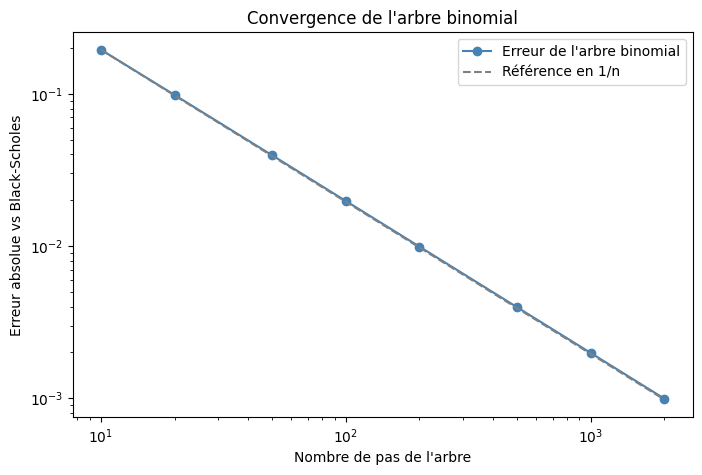

In [59]:
steps_list = [10, 20, 50, 100, 200, 500, 1000, 2000]     # nombres de pas testés (tous pairs : un arbre à nombre impair de pas oscille autour de la vraie valeur)

resultats_arbre = []                                       # un dict par nombre de pas
for n in steps_list:
    prix = binomial_price(S0, K, T, r, sigma, q, "call", american=False, n_steps=n)   # prix du call européen avec n pas
    resultats_arbre.append({
        "Pas": n,
        "Prix arbre": prix,
        "Erreur absolue": abs(prix - prix_call_bs),         # écart à Black-Scholes : ici déterministe, pas de tirage aléatoire
    })

df_arbre = pd.DataFrame(resultats_arbre)
print(df_arbre.to_string(index=False))

# pente en échelle log-log : la théorie dit -1 (erreur en 1/n)
pente_arbre = np.polyfit(np.log(df_arbre["Pas"]), np.log(df_arbre["Erreur absolue"]), 1)[0]
print(f"Pente de l'erreur en log-log : {pente_arbre:.3f} (théorie : -1)")

fig, ax = plt.subplots(figsize=(8, 5))
ax.loglog(df_arbre["Pas"], df_arbre["Erreur absolue"], marker="o", color="steelblue", label="Erreur de l'arbre binomial")
ref = df_arbre["Erreur absolue"].iloc[0] * df_arbre["Pas"].iloc[0] / df_arbre["Pas"]   # courbe 1/n ancrée sur le 1er point
ax.loglog(df_arbre["Pas"], ref, linestyle="--", color="gray", label="Référence en 1/n")
ax.set_xlabel("Nombre de pas de l'arbre")
ax.set_ylabel("Erreur absolue vs Black-Scholes")
ax.set_title("Convergence de l'arbre binomial")
ax.legend()
plt.savefig("convergence_arbre.png", dpi=150, bbox_inches="tight")   # on sauvegarde avant d'afficher
plt.show()

## 6. Les Greeks

Les Greeks mesurent de combien le prix de l'option bouge quand un paramètre change d'une petite quantité. Pour une option vanille, Black-Scholes donne des **formules fermées**. On les calcule de deux façons et on vérifie qu'elles concordent :

1. **par formule analytique** (exacte) ;
2. **par différences finies** (« bump-and-reval », la méthode utilisée dans le projet autocall, où il n'existe pas de formule) : on reprice avec un paramètre légèrement modifié et on regarde de combien le prix a bougé.

| Greek | Mesure la sensibilité à | Unité utilisée ici |
|---|---|---|
| Delta | prix du sous-jacent | variation du prix de l'option pour +1 sur le spot |
| Gamma | delta lui-même | variation du delta pour +1 sur le spot |
| Vega | volatilité | variation du prix pour +1 point de volatilité (par ex. 20 % → 21 %) |
| Theta | temps | variation du prix pour **1 jour** de moins |
| Rho | taux d'intérêt | variation du prix pour +1 point de taux |

**Convention d'unité** : on exprime vega et rho « par point » et theta « par jour », comme sur un desk. Les formules brutes donnent le vega par unité de volatilité (soit 100 points) et le theta par an : il faut donc les diviser par 100 et par 365. C'est exactement l'erreur d'unité qu'on a corrigée sur le vega de l'autocall.

**Ce qu'on s'attend à voir** :
- delta du call entre 0 et 1, delta du put entre -1 et 0 (et `delta call − delta put = 1` sans dividende) ;
- gamma et vega **identiques** pour un call et un put de même strike ;
- theta négatif : à marché inchangé, l'option perd de la valeur avec le temps.

In [60]:
def bs_greeks(S0, K, T, r, sigma, q=0.0, option_type="call"):
    d1 = (np.log(S0 / K) + (r - q + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))   # mêmes d1 et d2 que dans la formule de prix
    d2 = d1 - sigma * np.sqrt(T)
    pdf = norm.pdf(d1)                                  # densité de la loi normale en d1 (intervient dans gamma, vega, theta)

    if option_type == "call":
        delta = np.exp(-q * T) * norm.cdf(d1)           # entre 0 et 1
        theta = (-S0 * np.exp(-q * T) * pdf * sigma / (2 * np.sqrt(T))
                 - r * K * np.exp(-r * T) * norm.cdf(d2)
                 + q * S0 * np.exp(-q * T) * norm.cdf(d1))          # theta annuel du call
        rho = K * T * np.exp(-r * T) * norm.cdf(d2)     # rho (par unité de taux, soit 100 points)
    else:
        delta = -np.exp(-q * T) * norm.cdf(-d1)         # entre -1 et 0
        theta = (-S0 * np.exp(-q * T) * pdf * sigma / (2 * np.sqrt(T))
                 + r * K * np.exp(-r * T) * norm.cdf(-d2)
                 - q * S0 * np.exp(-q * T) * norm.cdf(-d1))         # theta annuel du put
        rho = -K * T * np.exp(-r * T) * norm.cdf(-d2)

    gamma = np.exp(-q * T) * pdf / (S0 * sigma * np.sqrt(T))        # identique pour call et put
    vega = S0 * np.exp(-q * T) * pdf * np.sqrt(T)                   # identique pour call et put (par unité de volatilité)

    return {"Delta": delta, "Gamma": gamma,
            "Vega": vega / 100,                         # par point de volatilité
            "Theta": theta / 365,                       # par jour
            "Rho": rho / 100}                           # par point de taux

def bs_greeks_fd(S0, K, T, r, sigma, q=0.0, option_type="call"):
    h = 0.01 * S0                                       # bump de 1% sur le spot
    prix = lambda S=S0, t=T, rr=r, s=sigma: black_scholes(S, K, t, rr, s, q, option_type)   # raccourci : reprice avec un paramètre modifié
    delta = (prix(S=S0 + h) - prix(S=S0 - h)) / (2 * h)                       # différence centrée
    gamma = (prix(S=S0 + h) - 2 * prix() + prix(S=S0 - h)) / h**2            # dérivée seconde
    vega = prix(s=sigma + 0.01) - prix()                                      # +1 point de vol, pas de division
    theta = prix(t=T - 1 / 365) - prix()                                      # 1 jour de moins
    rho = prix(rr=r + 0.01) - prix()                                          # +1 point de taux
    return {"Delta": delta, "Gamma": gamma, "Vega": vega, "Theta": theta, "Rho": rho}

lignes = []
for typ in ["call", "put"]:
    ana = bs_greeks(S0, K, T, r, sigma, q, typ)
    fd = bs_greeks_fd(S0, K, T, r, sigma, q, typ)
    for nom in ana:
        lignes.append({"Option": typ, "Greek": nom, "Analytique": round(ana[nom], 4), "Différences finies": round(fd[nom], 4)})

print(pd.DataFrame(lignes).to_string(index=False))

Option Greek  Analytique  Différences finies
  call Delta      0.5987              0.5986
  call Gamma      0.0193              0.0193
  call  Vega      0.3867              0.3868
  call Theta     -0.0147             -0.0147
  call   Rho      0.5046              0.5117
   put Delta     -0.4013             -0.4014
   put Gamma      0.0193              0.0193
   put  Vega      0.3867              0.3868
   put Theta     -0.0068             -0.0068
   put   Rho     -0.4659             -0.4540


### Comment les Greeks changent avec le prix du sous-jacent

Les Greeks ne sont pas constants : ils dépendent de la position du spot par rapport au strike. On les calcule pour un call de strike 100 en faisant varier le spot de 60 à 140.

**Ce qu'on observe et pourquoi** :
- **Delta** : il passe de 0 (option très hors de la monnaie : elle a peu de chances d'être exercée) à 1 (très dans la monnaie : elle se comporte comme l'action elle-même). Le delta s'interprète comme une probabilité d'exercice approximative.
- **Gamma** : maximal **près de la monnaie** (ici vers 91,5), faible loin de la monnaie. C'est là que le delta change le plus vite : un petit mouvement du spot suffit à faire basculer l'option d'un côté ou de l'autre, donc la couverture doit être réajustée le plus souvent.
- **Vega** : maximal près de la monnaie (ici vers 99). Loin de la monnaie, la volatilité change peu la probabilité d'exercice, donc peu le prix.
- **Theta** : toujours négatif pour un call, et le plus négatif près de la monnaie (ici vers 105) : c'est là que la valeur temps est la plus grande, donc la plus exposée à l'érosion.

**Nuance** : les maxima ne tombent pas exactement sur le spot = strike. Le prix d'un actif suit une loi log-normale (asymétrique) et le taux d'intérêt décale l'ensemble : les sommets sont proches de la monnaie, pas rigoureusement dessus.

        Delta   Gamma    Vega   Theta     Rho
60.0   0.0106  0.0023  0.0168 -0.0005  0.0060
80.0   0.1933  0.0171  0.2194 -0.0072  0.1390
100.0  0.5987  0.0193  0.3867 -0.0147  0.5046
120.0  0.8773  0.0085  0.2438 -0.0133  0.8073
140.0  0.9733  0.0022  0.0863 -0.0100  0.9301
Gamma maximal pour un spot de 91.5
Vega maximal pour un spot de 99.0
Theta le plus négatif pour un spot de 105.0


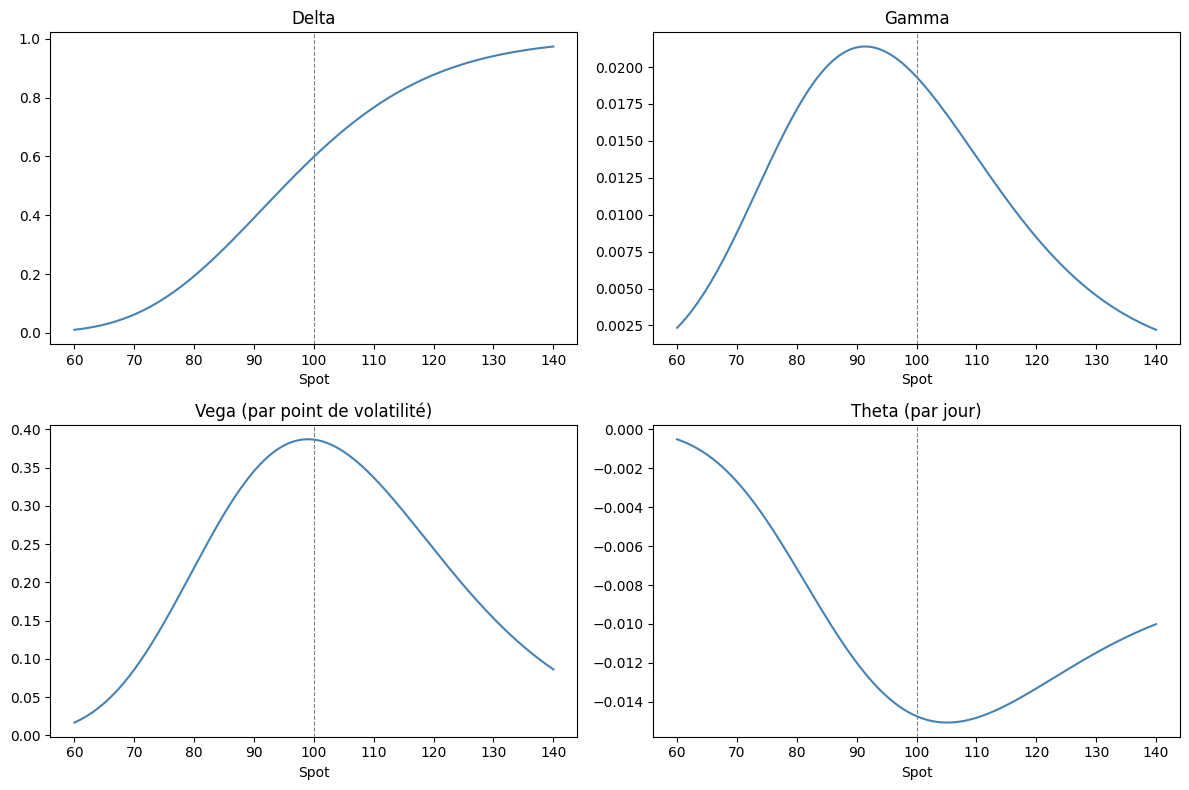

In [61]:
spots = np.linspace(60, 140, 161)                       # spots de 60 à 140 par pas de 0.5
greeks_spot = pd.DataFrame(
    [bs_greeks(s, K, T, r, sigma, q, "call") for s in spots],   # on recalcule les Greeks du call pour chaque spot
    index=spots
)

print(greeks_spot.loc[[60, 80, 100, 120, 140]].round(4))        # quelques points de repère
print(f"Gamma maximal pour un spot de {greeks_spot['Gamma'].idxmax()}")
print(f"Vega maximal pour un spot de {greeks_spot['Vega'].idxmax()}")
print(f"Theta le plus négatif pour un spot de {greeks_spot['Theta'].idxmin()}")

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
titres = {"Delta": "Delta", "Gamma": "Gamma", "Vega": "Vega (par point de volatilité)", "Theta": "Theta (par jour)"}
for ax, (col, titre) in zip(axes.ravel(), titres.items()):
    ax.plot(spots, greeks_spot[col], color="steelblue")          # courbe du Greek en fonction du spot
    ax.axvline(K, color="gray", linestyle="--", linewidth=0.8)   # ligne verticale au strike (à la monnaie)
    ax.set_title(titre)
    ax.set_xlabel("Spot")
plt.tight_layout()
plt.savefig("greeks_spot.png", dpi=150, bbox_inches="tight")     # on sauvegarde avant d'afficher
plt.show()

## 7. Option américaine : la prime d'exercice anticipé

On compare le put américain et le put européen pour des spots de 60 à 140, avec l'arbre à 500 pas. La **prime d'exercice anticipé** est la différence de prix : ce que vaut en plus le droit d'exercer avant l'échéance.

**Pourquoi un put américain vaut plus** : quand le put est très dans la monnaie (spot bas), l'investisseur a intérêt à l'exercer tout de suite pour encaisser `K − S` et placer cet argent au taux sans risque, plutôt que d'attendre un an. Un put européen ne peut pas faire ça : sa valeur peut même passer **sous** sa valeur intrinsèque `K − S` (on l'a vu : à un spot de 60, le put européen vaut 37,09 alors que `K − S = 40`). Le put américain, lui, ne descend jamais sous la valeur intrinsèque, car il pourrait être exercé immédiatement.

**Ce qu'on s'attend à voir** :
- la prime est maximale quand le spot est bas (option très dans la monnaie) et tend vers 0 quand le spot est élevé (option hors de la monnaie : l'exercice anticipé n'a plus d'intérêt) ;
- à spot bas, le put américain **colle à la valeur intrinsèque** `K − S` : à cet endroit, l'exercice immédiat est optimal.

**Pour le call sans dividende** : la prime est nulle (on l'a vu plus haut : 9,4094 pour le call américain comme pour l'européen), car il n'est jamais optimal d'exercer un call avant l'échéance si l'action ne verse pas de dividende.

       Put européen  Put américain   Prime
60.0        37.0851        40.0000  2.9149
70.0        27.3957        30.0000  2.6043
80.0        18.6072        20.1112  1.5040
90.0        11.4912        12.1629  0.6717
100.0        6.4540         6.7411  0.2871
110.0        3.3306         3.4465  0.1159
120.0        1.5918         1.6371  0.0454
140.0        0.3050         0.3114  0.0064
Prime maximale : 2.9149 pour un spot de 60


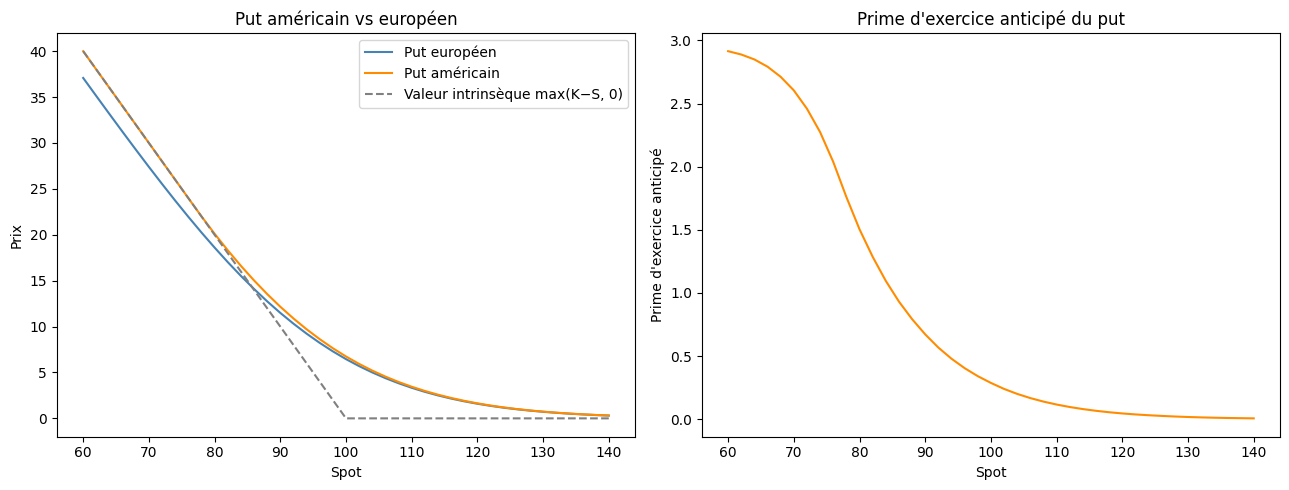

In [62]:
spots_p = np.linspace(60, 140, 41)                                                          # spots de 60 à 140 par pas de 2

put_eu_s = np.array([binomial_price(s, K, T, r, sigma, q, "put", american=False, n_steps=500) for s in spots_p])   # put européen à chaque spot
put_us_s = np.array([binomial_price(s, K, T, r, sigma, q, "put", american=True,  n_steps=500) for s in spots_p])   # put américain à chaque spot
prime = put_us_s - put_eu_s                                                                 # prime d'exercice anticipé

tableau_prime = pd.DataFrame({"Put européen": put_eu_s, "Put américain": put_us_s, "Prime": prime}, index=spots_p)
print(tableau_prime.loc[[60, 70, 80, 90, 100, 110, 120, 140]].round(4))
print(f"Prime maximale : {prime.max():.4f} pour un spot de {spots_p[prime.argmax()]:.0f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(spots_p, put_eu_s, label="Put européen", color="steelblue")
axes[0].plot(spots_p, put_us_s, label="Put américain", color="darkorange")
axes[0].plot(spots_p, np.maximum(K - spots_p, 0), linestyle="--", color="gray", label="Valeur intrinsèque max(K−S, 0)")   # ce que rapporterait un exercice immédiat
axes[0].set_xlabel("Spot")
axes[0].set_ylabel("Prix")
axes[0].set_title("Put américain vs européen")
axes[0].legend()

axes[1].plot(spots_p, prime, color="darkorange")
axes[1].set_xlabel("Spot")
axes[1].set_ylabel("Prime d'exercice anticipé")
axes[1].set_title("Prime d'exercice anticipé du put")

plt.tight_layout()
plt.savefig("prime_exercice.png", dpi=150, bbox_inches="tight")                            # on sauvegarde avant d'afficher
plt.show()

## 8. Comparaison des trois méthodes

On met côte à côte le prix du call et du put européens obtenu par chaque méthode, avec l'écart à la référence Black-Scholes. Trois lectures sont attendues :
- **Black-Scholes** est exact (aux hypothèses près) et instantané : c'est la référence.
- **Monte Carlo** donne une estimation aléatoire, à lire avec son erreur-type. Un écart de l'ordre d'une erreur-type est normal.
- **L'arbre** donne une approximation déterministe qui s'améliore en 1/n : toujours un peu en dessous de la vraie valeur pour cette option, et d'autant moins que le nombre de pas augmente.

**Le vrai critère de choix n'est pas la précision sur une option vanille** (Black-Scholes gagne toujours), mais ce que chaque méthode sait faire :

| Méthode | Options européennes | Options américaines | Produits path-dependent (autocall...) | Nombreux sous-jacents |
|---|---|---|---|---|
| Black-Scholes | oui (exact) | non | non | non |
| Arbre binomial | oui | **oui** | difficile | non (coût exponentiel) |
| Monte Carlo | oui | difficile (méthodes avancées) | **oui** | **oui** |

In [63]:
lignes = []
for typ in ["call", "put"]:
    bs_ref = black_scholes(S0, K, T, r, sigma, q, typ)                                 # référence exacte
    mc_prix, mc_se = monte_carlo_price(S0, K, T, r, sigma, q, typ, n_sims=1_000_000)   # Monte Carlo à 1 million de simulations
    bin_500 = binomial_price(S0, K, T, r, sigma, q, typ, american=False, n_steps=500)  # arbre à 500 pas
    bin_2000 = binomial_price(S0, K, T, r, sigma, q, typ, american=False, n_steps=2000)# arbre à 2000 pas
    lignes.append({"Option": typ,
                   "Black-Scholes": round(bs_ref, 4),
                   "Monte Carlo (1M)": round(mc_prix, 4),
                   "± erreur-type": round(mc_se, 4),
                   "Écart MC": round(mc_prix - bs_ref, 4),
                   "Arbre 500 pas": round(bin_500, 4),
                   "Écart 500": round(bin_500 - bs_ref, 4),
                   "Arbre 2000 pas": round(bin_2000, 4),
                   "Écart 2000": round(bin_2000 - bs_ref, 4)})

tableau_final = pd.DataFrame(lignes)
print(tableau_final.to_string(index=False))

put_us_2000 = binomial_price(S0, K, T, r, sigma, q, "put", american=True, n_steps=2000)    # put américain : seul l'arbre sait le faire
print(f"\nPut américain (arbre 2000 pas) : {put_us_2000:.4f}")

Option  Black-Scholes  Monte Carlo (1M)  ± erreur-type  Écart MC  Arbre 500 pas  Écart 500  Arbre 2000 pas  Écart 2000
  call         9.4134             9.398         0.0141   -0.0154         9.4094     -0.004          9.4124      -0.001
   put         6.4580             6.474         0.0094    0.0161         6.4540     -0.004          6.4570      -0.001

Put américain (arbre 2000 pas) : 6.7425


## Conclusion

### Ce que le projet a produit

On a implémenté « from scratch » trois méthodes de pricing d'options vanille et les Greeks, sur une option de référence (S = K = 100, T = 1 an, r = 3 %, σ = 20 %, sans dividende).

| | Call européen | Put européen | Put américain |
|---|---|---|---|
| Black-Scholes | 9,4134 | 6,4580 | n/a |
| Monte Carlo (1M simulations) | 9,3980 ± 0,0141 | 6,4740 ± 0,0094 | n/a |
| Arbre binomial (2 000 pas) | 9,4124 | 6,4570 | 6,7425 |

### Ce qu'on en retient

1. **Les trois méthodes convergent vers le même prix**, ce qui valide chaque implémentation. La parité call-put est respectée (9,4134 − 6,4580 = 2,9554 = S − K·e^(−rT)).
2. **L'erreur de Monte Carlo est aléatoire et suit 1/√N** : pente de l'erreur-type de -0,503 en échelle log-log (théorie : -0,5). L'erreur d'un seul tirage reste de l'ordre d'une erreur-type, mais ne décroît pas régulièrement : c'est pour cela qu'un prix Monte Carlo se donne toujours avec son erreur-type.
3. **L'erreur de l'arbre est déterministe et suit 1/n** : pente de -0,998. Doubler le nombre de pas divise l'erreur par 2.
4. **Un put américain vaut plus qu'un put européen** (6,7411 contre 6,4540 à 500 pas, soit une prime d'exercice anticipé de 0,2871), et la prime atteint 2,91 quand l'option est très dans la monnaie (spot de 60). Le call américain vaut le même prix que l'européen en l'absence de dividende.
5. **Les Greeks analytiques et par différences finies concordent** : delta 0,5987, gamma 0,0193, vega 0,3867 (par point de volatilité), theta -0,0147 (par jour) pour le call de référence. Le gamma, le vega et le theta sont maximaux (en valeur absolue) près de la monnaie, pas exactement au strike.

### Limites

- **Volatilité constante** : Black-Scholes ignore le smile de volatilité observé sur le marché (la volatilité implicite dépend du strike et de la maturité). Un modèle à volatilité locale ou stochastique (Dupire, Heston) serait la suite logique.
- **Une seule option de référence** (at-the-money, 1 an) et pas de dividende : le call américain n'a donc pas de prime d'exercice. Avec un dividende, il en aurait une.
- **Aucune donnée de marché** : les paramètres sont fixés à la main, sans calibration sur des cotations réelles d'options.
- **Monte Carlo simple** : sans réduction de variance (variables antithétiques, variables de contrôle), l'erreur ne décroît qu'en 1/√N.
- **Arbre CRR uniquement** : d'autres paramétrisations (Jarrow-Rudd, Tian) ou le lissage de Leisen-Reimer convergent plus vite que 1/n.

In [64]:
lignes_greeks = []                                                  # on reconstruit le tableau des Greeks (la variable `lignes` a été réutilisée par la cellule de comparaison)
for typ in ["call", "put"]:
    ana = bs_greeks(S0, K, T, r, sigma, q, typ)                     # Greeks analytiques
    fd = bs_greeks_fd(S0, K, T, r, sigma, q, typ)                   # Greeks par différences finies
    for nom in ana:
        lignes_greeks.append({"Option": typ, "Greek": nom, "Analytique": ana[nom], "Différences finies": fd[nom]})
tableau_greeks = pd.DataFrame(lignes_greeks)

df_convergence.to_csv("convergence_monte_carlo.csv", index=False)   # erreur-type de Monte Carlo selon N
df_arbre.to_csv("convergence_arbre.csv", index=False)               # erreur de l'arbre selon le nombre de pas
tableau_final.to_csv("comparaison_methodes.csv", index=False)       # comparaison des trois méthodes
tableau_greeks.to_csv("greeks_atm.csv", index=False)                # Greeks du call et du put de référence
greeks_spot.to_csv("greeks_selon_spot.csv")                         # Greeks du call selon le spot
tableau_prime.to_csv("prime_exercice_put.csv")                      # prime d'exercice anticipé selon le spot
print("Export terminé : 6 fichiers CSV")

Export terminé : 6 fichiers CSV
